# Olink NPX — affinity proteomics analysis

**Olink** is an *affinity* (antibody-based) proteomics platform built on the **Proximity Extension Assay (PEA)**. Each protein is detected by a pair of antibodies, each carrying a unique DNA oligo; when both antibodies bind the same target, the oligos hybridize, are extended by polymerase, and the resulting amplicon is quantified by qPCR or next-generation sequencing (Olink Explore). The readout is **NPX — Normalized Protein eXpression**, a relative abundance unit on an **arbitrary log2 scale**.

## How affinity proteomics differs from mass spectrometry

| Aspect | LC-MS/MS (discovery) | Olink PEA (affinity) |
|---|---|---|
| Targets | Whole detectable proteome, *unbiased* | Pre-defined antibody **panels** (≤ a few thousand proteins) |
| Quantity | Peptide intensities → protein summarization | Direct per-protein **NPX**, already on log2 scale |
| Missingness | High, often MNAR → needs imputation | **Low** — every assay measured in every sample |
| Batch effects | Run drift, normalization on intensities | Plate effects → **bridge normalization** across batches |
| Dynamic range | Wide, abundance-dependent | Excellent low-abundance sensitivity (cytokines, etc.) |

## Why it matters

Because PEA is sensitive, reproducible, and cheap per sample, it scales to **population proteomics**: the **UK Biobank Pharma Proteomics Project (UKB-PPP)** profiled ~3,000 plasma proteins in ~54,000 participants with Olink Explore. Multi-plate, multi-site studies at this scale make **QC** and **bridge normalization** central to the workflow.

This tutorial runs the complete OlinkAnalyze workflow on a real Olink Explore dataset (`npx_data1` from the OlinkAnalyze R package) using `omicverse`'s `ov.protein` module and the standalone `pyolinkanalyze` package. NPX data is **long-format**, so most `pyolinkanalyze` functions operate directly on the long DataFrame, while `ov.protein` works on a pivoted samples × proteins `AnnData`.

## 0. Imports

In [1]:
import omicverse as ov
import pyolinkanalyze as poa
import numpy as np
import pandas as pd
import anndata as adt
import matplotlib.pyplot as plt

## 1. Load NPX data

`ov.datasets.protein_olink()` returns the real OlinkAnalyze example dataset `npx_data1` as a **long-format** pandas DataFrame. Long format means **one row per (sample, protein)** measurement — not a sample × protein matrix. This is the native shape Olink delivers and the shape every `pyolinkanalyze` statistical function expects.

In [2]:
npx = ov.datasets.protein_olink()
print('shape:', npx.shape)
npx.head()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to ./data/protein_olink_npx.csv.gz
⚠️ File ./data/protein_olink_npx.csv.gz already exists
shape: (29440, 17)


,SampleID,Index,OlinkID,UniProt,Assay,MissingFreq,Panel_Version,PlateID,QC_Warning,LOD,NPX,Subject,Treatment,Site,Time,Project,Panel
0,A1,1,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,2.368467,12.956143,ID1,Untreated,Site_D,Baseline,data1,Olink Cardiometabolic
1,A2,2,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,2.368467,11.269477,ID1,Untreated,Site_D,Week.6,data1,Olink Cardiometabolic
2,A3,3,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,2.368467,25.451070,ID1,Untreated,Site_D,Week.12,data1,Olink Cardiometabolic
3,A4,4,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,2.368467,14.453038,ID2,Untreated,Site_C,Baseline,data1,Olink Cardiometabolic
4,A5,5,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,2.368467,7.628712,ID2,Untreated,Site_C,Week.6,data1,Olink Cardiometabolic


In [3]:
# Key long-format columns
print('columns:', list(npx.columns))
print('n unique assays (proteins):', npx['Assay'].nunique())
print('n unique samples         :', npx['SampleID'].nunique())

columns: ['SampleID', 'Index', 'OlinkID', 'UniProt', 'Assay', 'MissingFreq', 'Panel_Version', 'PlateID', 'QC_Warning', 'LOD', 'NPX', 'Subject', 'Treatment', 'Site', 'Time', 'Project', 'Panel']
n unique assays (proteins): 184
n unique samples         : 158


In [4]:
# Study design: group variable, sites, panels, plates
print('Treatment groups:'); print(npx['Treatment'].value_counts(dropna=False))
print('\nSites :', sorted(npx['Site'].dropna().unique()))
print('Panels:', list(npx['Panel'].unique()))
print('Plates:', npx['PlateID'].nunique(), '|', 'Timepoints:', list(npx['Time'].dropna().unique()))

Treatment groups:
Treatment
Untreated    16008
Treated      12696
NaN            736
Name: count, dtype: int64

Sites : ['Site_A', 'Site_B', 'Site_C', 'Site_D', 'Site_E']
Panels: ['Olink Cardiometabolic', 'Olink Inflammation']
Plates: 4 | Timepoints: ['Baseline', 'Week.6', 'Week.12']


**The NPX long format.** Each row carries the measurement (`NPX`) plus *all* identifying metadata: which sample (`SampleID`, `Subject`), which protein (`OlinkID`, `Assay`, `UniProt`), which panel/plate (`Panel`, `PlateID`, `Panel_Version`), per-assay QC (`MissingFreq`, `LOD`, `QC_Warning`), and the experimental design (`Treatment`, `Site`, `Time`).

This dataset spans **two panels** (Cardiometabolic + Inflammation, 184 assays total) across **4 plates** and **5 sites**, with a `Treatment` group variable (`Treated` vs `Untreated`). Note the two `CONTROL_SAMPLE_AS` rows have no `Treatment` — they are assay controls, not study subjects, and we exclude them from group comparisons.

## 2. Quality control

Olink QC works at two levels:

- **Sample-level** (`QC_Warning`): flags samples where internal incubation/detection controls deviate — these whole samples are suspect.
- **Assay-level** (`MissingFreq`, `LOD`): `MissingFreq` is the fraction of samples in which an assay fell below its **Limit Of Detection (LOD)**. Assays with high missing frequency carry little signal.

A core sanity check is the **per-sample NPX distribution**: each sample should have a similar median and spread. An outlying sample (technical failure, low input) shows up as a shifted or compressed boxplot.

In [5]:
# Sample-level QC warnings
qc = npx.drop_duplicates('SampleID')
print('QC_Warning by sample:')
print(qc['QC_Warning'].value_counts(dropna=False))
flagged = qc.loc[qc['QC_Warning'] != 'Pass', 'SampleID'].tolist()
print('\nflagged samples:', flagged if flagged else 'none')

QC_Warning by sample:
QC_Warning
Pass       157
Warning      1
Name: count, dtype: int64

flagged samples: ['A15']


In [6]:
# Assay-level missingness: fraction of samples below LOD per assay
assay_miss = npx.drop_duplicates('Assay')[['Assay', 'MissingFreq']]
print('MissingFreq summary across {} assays:'.format(len(assay_miss)))
print(assay_miss['MissingFreq'].describe()[['min', '50%', 'max']])
print('\nassays with MissingFreq > 0.05:', int((assay_miss['MissingFreq'] > 0.05).sum()))

MissingFreq summary across 184 assays:
min    0.00625
50%    0.05625
max    0.10000
Name: MissingFreq, dtype: float64

assays with MissingFreq > 0.05: 98


Missingness is **uniformly low** (max ~10%) — a hallmark of affinity proteomics: every assay is measured in every sample, so there is no MNAR imputation problem as in LC-MS/MS. Now the per-sample distribution plot via `pyolinkanalyze.olink_qc_plot`, which marks samples whose NPX IQR or median falls outside `iqr_mult`× the cohort spread.

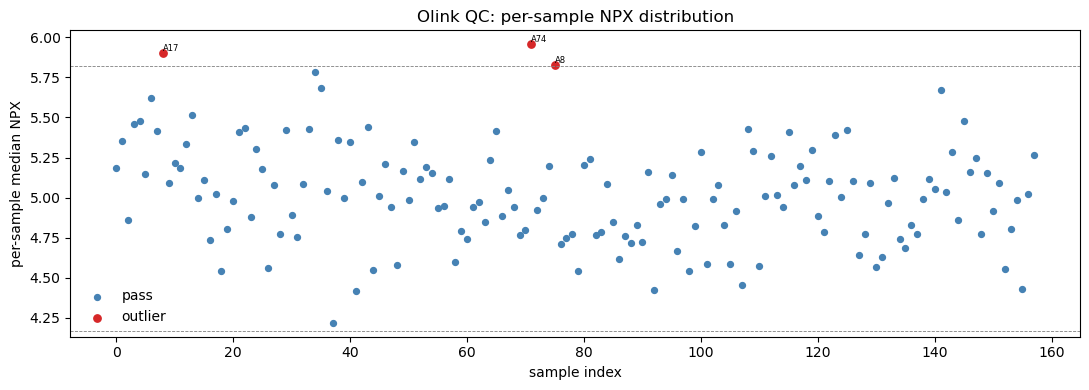

In [7]:
# Per-sample NPX distribution QC plot
fig, ax = plt.subplots(figsize=(11, 4))
poa.olink_qc_plot(npx, sample_col='SampleID', npx_col='NPX', iqr_mult=1.5, ax=ax)
ax.set_title('Olink QC: per-sample NPX distribution')
plt.tight_layout(); plt.show()

In [8]:
# LOD handling: NCLOD computes a negative-control-based LOD per assay
lod = poa.olink_lod(npx, lod_method='NCLOD', npx_col='NPX',
                    sample_col='SampleID', assay_col='OlinkID', sd_mult=3.0)
print('olink_lod output shape:', lod.shape)
lod[['OlinkID', 'Assay', 'LOD', 'PCNormalizedLOD']].drop_duplicates('OlinkID').head() \
    if 'PCNormalizedLOD' in lod else lod.head()

olink_lod output shape: (29440, 18)


,SampleID,Index,OlinkID,UniProt,Assay,MissingFreq,Panel_Version,PlateID,QC_Warning,LOD,NPX,Subject,Treatment,Site,Time,Project,Panel,below_LOD
0,A1,1,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,21.333559,12.956143,ID1,Untreated,Site_D,Baseline,data1,Olink Cardiometabolic,True
1,A2,2,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,21.333559,11.269477,ID1,Untreated,Site_D,Week.6,data1,Olink Cardiometabolic,True
2,A3,3,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,21.333559,25.451070,ID1,Untreated,Site_D,Week.12,data1,Olink Cardiometabolic,False
3,A4,4,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,21.333559,14.453038,ID2,Untreated,Site_C,Baseline,data1,Olink Cardiometabolic,True
4,A5,5,OID01216,O00533,CHL1,0.01875,v.1201,Example_Data_1_CAM.csv,Pass,21.333559,7.628712,ID2,Untreated,Site_C,Week.6,data1,Olink Cardiometabolic,True


`olink_lod` recomputes a Limit-Of-Detection per assay from negative controls (`NCLOD` = max negative-control NPX + `sd_mult`×SD). Comparing each measurement to its LOD lets you flag below-LOD values — useful for deciding which low-signal assays to drop before differential testing. Here we keep all assays since missingness is already low.

## 3. Bridge / batch normalization

Large Olink studies are run in **batches** — different plates, different runs, sometimes different sites or years. Each batch has its own systematic NPX offset. To make NPX comparable across batches you use **bridge normalization**:

1. Include a set of shared **bridging samples** (the same physical samples) on every batch.
2. For each assay, compute the **median NPX difference** of the bridge samples between the reference batch and the target batch.
3. Subtract that per-assay offset from the entire target batch.

Good bridge samples are **representative** (typical NPX, low below-LOD rate) so the offset they define generalizes. `pyolinkanalyze.olink_bridge_selector` picks them automatically.

In [9]:
# Drop assay controls; keep only study subjects for analysis
npx_s = npx[npx['Treatment'].notna() &
            ~npx['SampleID'].str.startswith('CONTROL')].copy()
print('analysis rows:', npx_s.shape, '| samples:', npx_s['SampleID'].nunique())

analysis rows: (28704, 17) | samples: 156


In [10]:
# Pick 8 representative bridging samples (low below-LOD fraction)
bridge = poa.olink_bridge_selector(npx_s, sample_missing_freq=0.1, n=8, seed=0)
bridge_ids = bridge['SampleID'].tolist()
print('selected bridge samples:', bridge_ids)
bridge

selected bridge samples: ['A70', 'A31', 'B16', 'A66', 'A72', 'B8', 'A26', 'B26']


,SampleID,PercAssaysBelowLOD,MeanNPX
0,A70,0.043478,6.304760
1,A31,0.021739,6.209815
2,B16,0.081522,6.251585
3,A66,0.070652,6.074096
4,A72,0.043478,6.136644
5,B8,0.059783,6.462233
6,A26,0.059783,6.366970
7,B26,0.054348,5.988154


This single dataset is one batch, so there is no second project to genuinely bridge to. To **demonstrate the mechanics honestly**, we construct a synthetic second batch by adding a uniform +0.7 NPX plate shift to a copy of the data. `olink_normalization_bridge` should then use the shared bridge samples to **detect and remove** that shift, restoring the two batches to a common scale.

In [11]:
# Synthetic second batch with a known +0.7 NPX plate offset
p1 = npx_s.copy()
p2 = npx_s.copy()
p2['NPX'] = p2['NPX'] + 0.7
print('mean NPX  P1: {:.3f}  |  P2 (shifted): {:.3f}'
      .format(p1['NPX'].mean(), p2['NPX'].mean()))

mean NPX  P1: 5.889  |  P2 (shifted): 6.589


In [12]:
# Bridge-normalize P2 onto P1 using the shared bridge samples
norm = poa.olink_normalization_bridge(
    p1, p2, bridge_samples=bridge_ids,
    project_1_name='P1', project_2_name='P2', project_ref_name='P1')
after = norm.groupby('Project')['NPX'].mean()
print('mean NPX after bridge normalization:')
print(after.round(3))

mean NPX after bridge normalization:
Project
P1    5.889
P2    5.889
Name: NPX, dtype: float64


After bridge normalization the two batches sit on the **same NPX scale** — the artificial +0.7 plate offset has been removed using only the 8 shared bridge samples. In a real multi-batch study this is what makes UKB-PPP-scale meta-analysis possible. `pyolinkanalyze` also offers `olink_normalization` (intensity/reference-median based) and `olink_normalization_reference_medians` for when no bridge samples are available.

## 4. Pivot to AnnData & explore

`pyolinkanalyze`'s statistical functions consume the long DataFrame, but for matrix-style exploration (PCA, heatmaps, `ov.protein` DE) we **pivot** the long NPX to a samples × proteins `AnnData`. We index on `SampleID`, spread `Assay` across columns, and attach the per-sample design (`Treatment`, `Site`, `Subject`, `Time`) to `obs`.

In [13]:
# Long -> wide pivot (samples x proteins)
wide = npx_s.pivot_table(index='SampleID', columns='Assay',
                         values='NPX', aggfunc='mean')
X = wide.to_numpy(dtype=float)
X = np.where(np.isnan(X), np.nanmean(X), X)  # fill the rare below-LOD gap
print('matrix:', X.shape, '| residual NaN:', int(np.isnan(X).sum()))

matrix: (156, 184) | residual NaN: 0


In [14]:
# Build AnnData with per-sample obs and per-protein var metadata
obs = (npx_s.drop_duplicates('SampleID').set_index('SampleID')
       [['Treatment', 'Site', 'Subject', 'Time', 'PlateID']]
       .reindex(wide.index).astype(str))
var = (npx_s.drop_duplicates('Assay').set_index('Assay')
       [['OlinkID', 'UniProt', 'Panel']].reindex(wide.columns))
adata = adt.AnnData(X=X, obs=obs, var=var)
adata

AnnData object with n_obs × n_vars = 156 × 184
    obs: 'Treatment', 'Site', 'Subject', 'Time', 'PlateID'
    var: 'OlinkID', 'UniProt', 'Panel'

In [15]:
# Median-center across samples. log2=False: NPX is ALREADY on a log2 scale!
ov.protein.normalize(adata, method='median', log2=False)
print('normalized; layers:', list(adata.layers.keys()))

normalized; layers: ['raw']


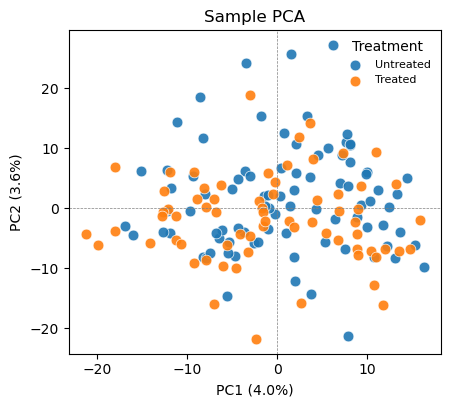

In [16]:
# PCA colored by the biological group of interest
ov.protein.pca_plot(adata, color='Treatment')
plt.show()

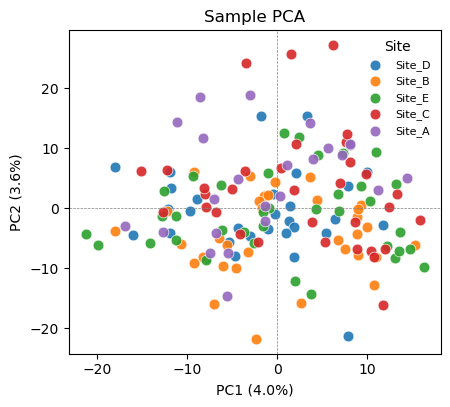

In [17]:
# PCA colored by Site -> check for a technical / batch axis
ov.protein.pca_plot(adata, color='Site')
plt.show()

Color the **same** PCA by the biological variable (`Treatment`) and by a potential technical variable (`Site`). If samples cluster by `Site` rather than `Treatment`, a site/batch effect is dominating the variance and should be regressed out (or handled with a mixed model) before interpreting group differences. If `Site` is well mixed, the cohort is comparable and the leading variance is biological. `pyolinkanalyze.olink_pca_plot` produces the equivalent plot directly from the long DataFrame.

## 5. Differential expression

Olink panels are **small** (here 184 assays) and missingness is **low**, so the standard approach is a **per-protein two-group test** — no peptide roll-up, no moderated variance borrowing strictly required. We run three complementary analyses:

- `pyolinkanalyze.olink_ttest` — Welch t-test per assay, on the long DataFrame.
- `pyolinkanalyze.olink_wilcox` — non-parametric Mann–Whitney, robust to non-normal NPX.
- `ov.protein.de(..., method='welch_t')` — the same Welch test on the pivoted `AnnData`.

All use Benjamini–Hochberg FDR. The first two and the third should agree.

In [18]:
# Per-protein Welch t-test on the long NPX DataFrame
tt = poa.olink_ttest(npx_s, variable='Treatment')
n_sig_tt = int((tt['Adjusted_pval'] < 0.05).sum())
print('olink_ttest  : {} / {} assays FDR < 0.05'.format(n_sig_tt, len(tt)))
tt.sort_values('p.value').head()

olink_ttest  : 14 / 184 assays FDR < 0.05


,OlinkID,Assay,UniProt,Panel,term,estimate,statistic,p.value,Adjusted_pval,Threshold
0,OID00488,TRAIL,P50591,Olink Inflammation,Untreated - Treated,2.639456,4.970362,0.000002,0.000171,1
1,OID01232,SERPINA7,P05543,Olink Cardiometabolic,Untreated - Treated,3.200750,4.978796,0.000002,0.000171,1
2,OID00486,CXCL11,O14625,Olink Inflammation,Untreated - Treated,-1.718869,-4.309713,0.000030,0.001814,1
3,OID00527,MMP-10,P09238,Olink Inflammation,Untreated - Treated,2.149888,4.054861,0.000085,0.003903,1
4,OID00499,CD6,Q8WWJ7,Olink Inflammation,Untreated - Treated,-0.889727,-3.989178,0.000106,0.003903,1


In [19]:
# Non-parametric Mann-Whitney as a robustness check
wx = poa.olink_wilcox(npx_s, variable='Treatment')
n_sig_wx = int((wx['Adjusted_pval'] < 0.05).sum())
print('olink_wilcox : {} / {} assays FDR < 0.05'.format(n_sig_wx, len(wx)))

olink_wilcox : 13 / 184 assays FDR < 0.05


In [20]:
# Same Welch test via ov.protein.de on the pivoted AnnData
de = ov.protein.de(adata, group='Treatment', method='welch_t')
n_sig_de = int((de['adj.P.Val'] < 0.05).sum())
print('ov.protein.de: {} / {} assays FDR < 0.05'.format(n_sig_de, len(de)))
de.sort_values('P.Value').head()

ov.protein.de: 12 / 184 assays FDR < 0.05


,gene,logFC,AveExpr,t,P.Value,adj.P.Val
0,SERPINA7,3.144091,10.825873,4.910163,0.000003,0.000251
1,TRAIL,2.582797,8.853974,4.883764,0.000003,0.000251
2,CXCL11,-1.775528,4.639429,-4.478312,0.000015,0.000911
3,CD6,-0.946386,2.219474,-4.203037,0.000047,0.002163
4,Flt3L,-2.016890,5.019380,-4.046551,0.000083,0.003064


In [21]:
# Cross-check: do the long-format and AnnData Welch tests agree?
cmp = (tt.set_index('Assay')[['p.value']]
         .join(de.set_index('gene')[['P.Value']], how='inner'))
r = np.corrcoef(np.log10(cmp['p.value']), np.log10(cmp['P.Value']))[0, 1]
print('correlation of log10 p-values (olink_ttest vs ov.protein.de): {:.4f}'.format(r))
print('=> the two implementations agree.')

correlation of log10 p-values (olink_ttest vs ov.protein.de): 0.9889
=> the two implementations agree.


In [22]:
# Multi-level factor: one-way ANOVA across the 5 Sites
an = poa.olink_anova(npx_s, variable='Site')
print('olink_anova (Site, 5 levels): {} / {} assays FDR < 0.05'
      .format(int((an['Adjusted_pval'] < 0.05).sum()), len(an)))
an.sort_values('p.value')[['Assay', 'statistic', 'p.value', 'Adjusted_pval']].head()

olink_anova (Site, 5 levels): 22 / 184 assays FDR < 0.05


,Assay,statistic,p.value,Adjusted_pval
0,TRAIL,8.137222,0.000006,0.001053
1,CCL18,7.359446,0.000019,0.001280
2,MCP-1,7.180249,0.000026,0.001280
3,PLXNB2,7.124786,0.000028,0.001280
5,IL13,5.355663,0.000464,0.014184


The Welch t-test on the long DataFrame and on the `AnnData` give effectively identical p-values — a useful consistency check between the two entry points. `olink_anova` extends the same idea to a multi-level factor (`Site`); for repeated-measures designs (`Subject` measured at `Baseline`/`Week.6`/`Week.12`) `pyolinkanalyze.olink_lmer` fits a per-protein linear mixed model with `Subject` as a random effect.

## 6. Visualization

Standard DE visuals: a **volcano plot** (effect size vs significance) to see overall structure, and a **heatmap** of the top hits to inspect their per-sample pattern.

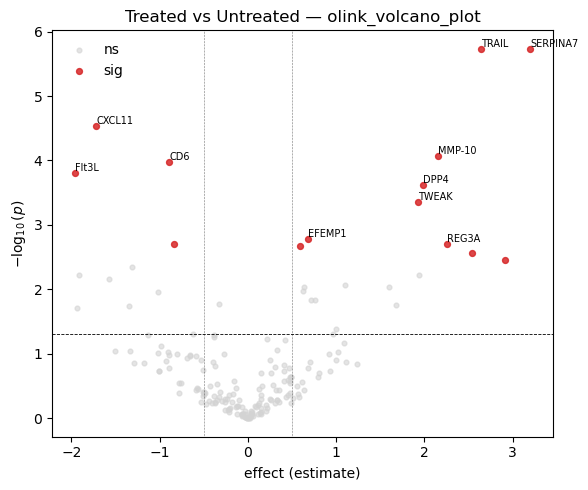

In [23]:
# Volcano plot from the long-format t-test result
fig, ax = plt.subplots(figsize=(6, 5))
poa.olink_volcano_plot(tt, estimate_col='estimate', p_col='p.value',
                       label_col='Assay', threshold=0.05,
                       abs_fc_cutoff=0.5, n_label=10, ax=ax)
ax.set_title('Treated vs Untreated — olink_volcano_plot')
plt.tight_layout(); plt.show()

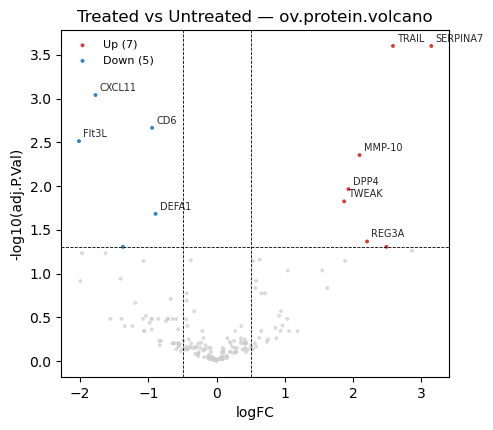

In [24]:
# Equivalent volcano from the ov.protein.de result
ov.protein.volcano(de, fc_col='logFC', p_col='adj.P.Val', raw_p_col='P.Value',
                   gene_col='gene', logfc_threshold=0.5, adj_p_threshold=0.05,
                   label_top=10, title='Treated vs Untreated — ov.protein.volcano')
plt.show()

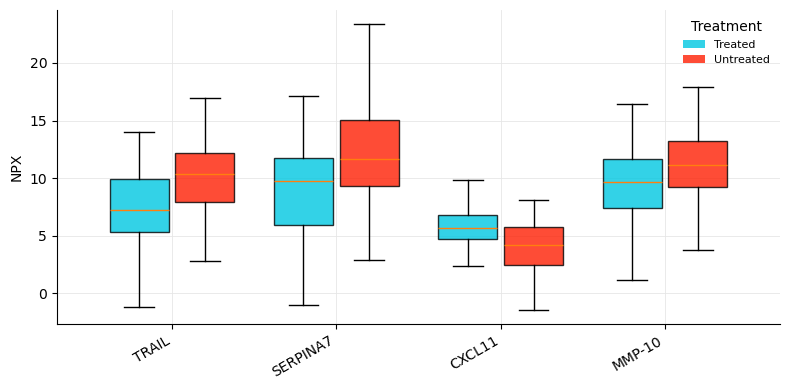

In [25]:
# Boxplots of the top differential assays across Treatment
top_ids = tt.sort_values('p.value').head(4)['OlinkID'].tolist()
fig, ax = plt.subplots(figsize=(8, 4))
poa.olink_boxplot(npx_s, variable='Treatment', olinkids=top_ids,
                  label_col='Assay', ax=ax)
plt.tight_layout(); plt.show()

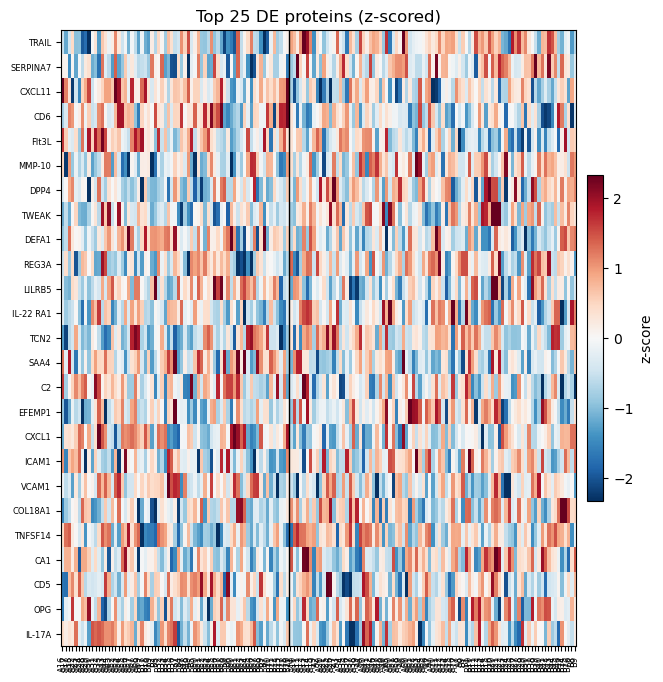

In [26]:
# Heatmap of the top DE proteins (z-scored per protein)
ov.protein.heatmap(adata, de, group='Treatment', n_top=25,
                   gene_col='gene', p_col='adj.P.Val')
plt.show()

## 7. Pathway enrichment

To move from a list of significant proteins to **biology**, test whether the hits are enriched for known gene sets. `pyolinkanalyze.olink_pathway_enrichment` takes the DE result plus a `gene_sets` dictionary (`{set_name: [gene symbols]}`) and runs over-representation (`ora`) or GSEA.

Real analyses supply curated gene sets — **MSigDB Hallmark / Reactome / GO**, loadable with `pyolinkanalyze.read_gmt('hallmark.gmt')`. Those `.gmt` files are not bundled offline, so here we build small **illustrative** sets directly from the data to demonstrate the call; swap in a real `.gmt` for production use.

In [27]:
# Illustrative gene sets (replace with read_gmt('hallmark.gmt') in practice)
ranked = tt.sort_values('p.value')
gene_sets = {
    'Top_DE_signature': ranked.head(20)['Assay'].tolist(),
    'Inflammation_panel': npx_s.loc[npx_s['Panel'].str.contains('Inflamm'),
                                    'Assay'].unique().tolist(),
    'Cardiometabolic_panel': npx_s.loc[npx_s['Panel'].str.contains('Cardio'),
                                       'Assay'].unique().tolist(),
}
print({k: len(v) for k, v in gene_sets.items()})

{'Top_DE_signature': 20, 'Inflammation_panel': 92, 'Cardiometabolic_panel': 92}


In [28]:
# Over-representation test of the significant proteins against the gene sets
enr = poa.olink_pathway_enrichment(
    tt, gene_sets=gene_sets, method='ora',
    gene_col='Assay', estimate_col='estimate', p_col='p.value',
    pvalue_cutoff=0.05, min_size=3)
enr[['Description', 'setSize', 'Count', 'GeneRatio', 'pvalue', 'p.adjust']]

,Description,setSize,Count,GeneRatio,pvalue,p.adjust
0,Top_DE_signature,20,20,20/32,8.103508e-19,2.431052e-18
1,Inflammation_panel,92,16,16/32,5.769672e-01,5.769672e-01
2,Cardiometabolic_panel,92,16,16/32,5.769672e-01,5.769672e-01


The result shows, for each gene set, how many of the significant proteins it contains (`Count` / `GeneRatio`) and the over-representation p-value. With a curated database (`read_gmt` of MSigDB/Reactome/GO) this is how Olink hits are mapped to inflammatory, cardiometabolic, or immune pathways. `ov.protein.enrich` offers an alternative entry point that scores enrichment activity directly on the `AnnData` using `decoupler`-style methods.

## Summary

**The Olink NPX workflow recipe:**

1. **Load** the long-format NPX table (`ov.datasets.protein_olink()` here; `pyolinkanalyze.read_npx_*` for real files).
2. **QC** — sample-level `QC_Warning`, assay-level `MissingFreq`/`LOD` (`olink_qc_plot`, `olink_lod`).
3. **Bridge-normalize** across plates/batches with `olink_bridge_selector` + `olink_normalization_bridge`.
4. **Pivot** to a samples × proteins `AnnData`; explore with `pca_plot` (biology vs batch).
5. **Differential expression** per protein — `olink_ttest` / `olink_wilcox` / `olink_anova` / `olink_lmer`, or `ov.protein.de`.
6. **Visualize** — `olink_volcano_plot`, `olink_boxplot`, `ov.protein.heatmap`.
7. **Pathway enrichment** with `olink_pathway_enrichment` against MSigDB/Reactome/GO.

**How affinity proteomics differs from the LC-MS/MS tutorials:**

| LC-MS/MS workflow | Olink PEA workflow |
|---|---|
| Peptide → protein **summarization** | None — NPX is already per-protein |
| log2 **transform** intensities | None — NPX is *already* log2 (`log2=False`) |
| **MNAR imputation** of many missing values | Not needed — missingness is low |
| Intensity / median normalization | **Bridge normalization** across plates/batches |
| Whole proteome, abundance-biased | Targeted panels, sensitive to low-abundance proteins |

**Related tutorials:** `t_protein_01`–`t_protein_04` cover the mass-spectrometry side — reading MaxQuant/DIA-NN/FragPipe output, peptide summarization, MNAR-aware imputation, and DEqMS/limma differential expression. Use those for discovery LC-MS/MS; use this Olink workflow for targeted, population-scale affinity proteomics.